<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 10 - Clustering

## Download the dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)
!cp -r $path /content/
!mv ./1/dataset.csv ./
# !mv $path/dataset.csv ./
# !rm -r ~spotify-tracks-dataset

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset
mv: cannot stat './1/dataset.csv': No such file or directory


## Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np

## Q1 - Dataframe preprocessing

In [3]:
og_df = pd.read_csv('dataset.csv')
df = og_df.drop(columns=['track_id', 'Unnamed: 0', 'artists', 'album_name', 'track_name'])
info_df = og_df[['track_id', 'Unnamed: 0', 'artists', 'album_name', 'track_name']]
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = enc.fit_transform(df[["track_genre"]])
encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(["track_genre"]))

df = df.drop(columns=["track_genre"]).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Q2 - Normalize features
We will use a StandardScaler on the appropriate features: popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo

In [4]:
scale_cols = [
    'popularity','duration_ms','danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

## Q3 - K-Means

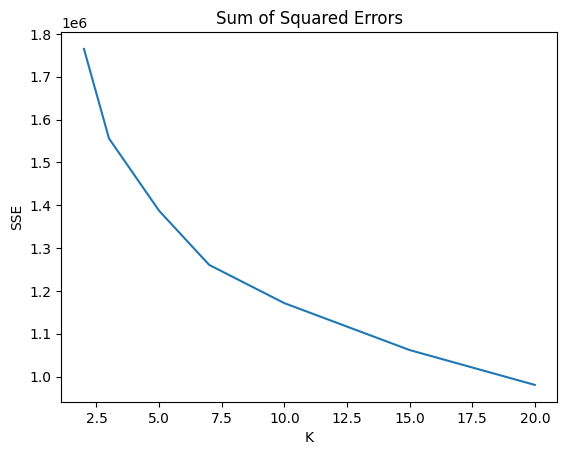

In [5]:
Ks = [2,3,5,7,10,15,20]
results = []
for k in Ks:
  kmean = KMeans(n_clusters=k, )
  kmean.fit(df)
  results.append(kmean.inertia_)

plt.plot(Ks, results)
plt.title("Sum of Squared Errors")
plt.xlabel("K")
plt.ylabel("SSE")
plt.show();

## Q4 - Select best value of `k`
Based on the plot above and the elbow method, the best value of `k` is 10.

In [14]:
k = 10 # best value per elbow method
model = KMeans(n_clusters=k)
model.fit(df)
# print(len(model.labels_))
labels = model.labels_
labels

array([1, 5, 5, ..., 5, 3, 5], dtype=int32)

## Q5 - Calculate main genre per cluster

In [15]:
df["cluster"] = labels

genre_cols = [c for c in df.columns if c.startswith("track_genre")]

dominant_pct = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .max(axis=1) * 100
)

dominant_genre = (
    df.groupby("cluster")[genre_cols]
    .mean()
    .idxmax(axis=1)
    .str.replace("track_genre_", "")
)

result = pd.DataFrame({
    "genre": dominant_genre,
    "percentage": dominant_pct
})

print(result)

                 genre  percentage
cluster                           
0        chicago-house    1.637537
1          death-metal    1.456289
2                sleep   13.245758
3               latino    2.244637
4           honky-tonk    3.101470
5                tango    3.147877
6                 soul    1.311953
7              new-age   11.175682
8          black-metal    4.440027
9                sleep   11.942578


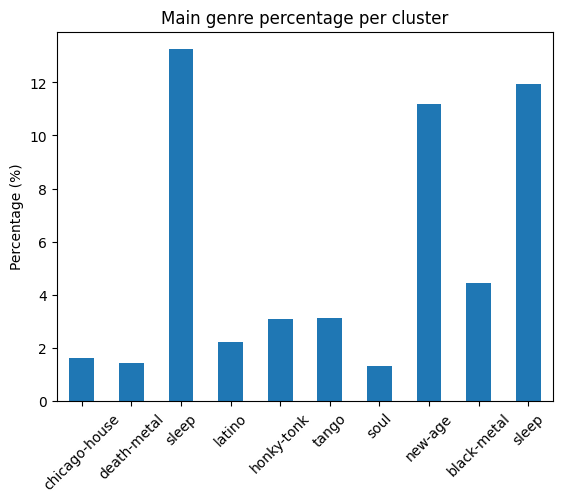

In [16]:
result.plot(
    kind="bar",
    y="percentage",
    legend=False
)
plt.xticks(range(len(result)), result["genre"], rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Main genre percentage per cluster")
plt.xlabel("")
plt.show()

## Q6 - Recommend top-3 similar songs

In [24]:
feature_cols = df.columns.tolist()
top3_df = pd.concat([info_df.reset_index(drop=True), df.reset_index(drop=True)], axis=1)

# build feature matrix aligned exactly to training columns
X_all = df.reindex(columns=feature_cols).values

idx = 0
song_vec = X_all[idx]
label = model.predict(song_vec.reshape(1, -1))[0]

same = top3_df[top3_df["cluster"] == label].copy()
X_same = same.reindex(columns=feature_cols).values

same["dist"] = np.sum((X_same - song_vec) ** 2, axis=1)
same = same[same.index != idx]

top3 = same.nsmallest(3, "dist")
top3[["track_name", "artists", "album_name", "dist"]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


TypeError: Column 'dist' has dtype object, cannot use method 'nsmallest' with this dtype

## Q7 - Recommend top-3 via cosine distance

## Q8 - Use `elbow` for k-group selection

## Q9 - Perform DBScan for clustering

## Q10 - Perform DBScan++ (BONUS)